# Notebook 24 — Pillar K: King 2012 Subset Sensitivity Scan

**Tension between Pillars A and B.** Pillar A (Wang's 128-absorber subset) found $\Delta\chi^2 = 31.5$ vs constant null, while Pillar B (the full King+ 2012 295-absorber catalog) found $\Delta\chi^2 \approx 0$ and $\Delta {\rm BIC} = +5.7$ favoring null. We did not have the original 128-absorber selection list, so we cannot reproduce Pillar~A on the King catalog directly. Instead, we **scan plausible cuts** and ask: which cuts yield the largest Pillar-A-like Γ signal, and which suppress it?

**Cuts considered:**
1. **Sample**: VLT only / Keck only / both
2. **Per-absorber error threshold**: $\sigma_{\rm rand} < 1, 2, 3, \infty$
3. **Redshift bins**: $z < 1$ / $1 \le z < 2$ / $z \ge 2$ / all
4. **Random subsamples of 128**: 100 trials

If the Wang-128 subset's high-Γ signal is robust, most plausible cuts should reproduce it. If it is selection-driven, only specific cuts (or no cut at all) will.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family':'serif','font.size':10,'figure.dpi':140})

t_P = 5.391e-44; t_now = 4.354e17
ln_n0 = np.log(t_now/t_P)
xi_now = 1.0/ln_n0**2

In [2]:
# Load full King+ 2012 (CDS J/MNRAS/422/3370 tablea1)
rows=[]
with open('KingJ_12a_VLT+Keck.dat') as f:
    for line in f:
        line=line.strip()
        if not line or line.startswith('#'): continue
        rows.append(line.split())
z_abs    = np.array([float(r[3]) for r in rows])
da_a     = np.array([float(r[4]) for r in rows])
err_stat = np.array([float(r[5]) for r in rows])
sample   = np.array([r[6] for r in rows])
med = np.median(da_a)
mask_clean = np.abs(da_a - med) < 3*(err_stat + np.std(da_a))
z_abs, da_a, err_stat, sample = z_abs[mask_clean], da_a[mask_clean], err_stat[mask_clean], sample[mask_clean]
sig_rand = np.where(sample == 'VLT', 0.905, 1.743)
sig_total = np.sqrt(err_stat**2 + sig_rand**2)
N = len(z_abs)
print(f'King+ 2012 cleaned: N = {N}  (VLT={(sample=="VLT").sum()}, Keck={(sample=="Keck").sum()})')
print(f'  z range: [{z_abs.min():.3f}, {z_abs.max():.3f}]')

King+ 2012 cleaned: N = 295  (VLT=154, Keck=141)
  z range: [0.222, 4.180]


In [3]:
def t_age(z):
    return t_now / (1+z)**1.5
def model_alpha_drift(z, Gamma):
    return -Gamma * (1.0/np.log(t_age(z)/t_P)**2 - xi_now) * 1e5  # in units of 10^-5

def fit_subset(idx):
    z, y, s = z_abs[idx], da_a[idx], sig_total[idx]
    if len(z) < 3:
        return dict(N=len(z), Gamma=np.nan, sigGamma=np.nan, chi2_null=np.nan, chi2_dsc=np.nan, dchi2=np.nan)
    chi2_null = float(np.sum((y / s)**2))
    def chi2_dsc(p): return float(np.sum(((y - model_alpha_drift(z, p[0]))/s)**2))
    res = minimize(chi2_dsc, [1.0], method='Nelder-Mead')
    Gamma = res.x[0]; chi2_d = res.fun
    eps = 1e-3
    sigG = 1.0 / np.sqrt(0.5*(chi2_dsc([Gamma+eps]) + chi2_dsc([Gamma-eps]) - 2*chi2_d) / eps**2)
    return dict(N=len(z), Gamma=Gamma, sigGamma=sigG, chi2_null=chi2_null, chi2_dsc=chi2_d,
                dchi2=chi2_null - chi2_d)

scan = []
scan.append(('Full sample (Pillar B)', fit_subset(np.arange(N))))
scan.append(('VLT only',                fit_subset(sample=='VLT')))
scan.append(('Keck only',               fit_subset(sample=='Keck')))
for sig_cut in [0.5, 1.0, 1.5, 2.0]:
    sel = err_stat < sig_cut
    scan.append((f'σ_stat < {sig_cut:.1f}', fit_subset(sel)))
for zlo, zhi in [(0,1),(1,2),(2,3.5),(0,1.5),(1.5,3.5)]:
    sel = (z_abs>=zlo) & (z_abs<zhi)
    scan.append((f'{zlo} ≤ z < {zhi}', fit_subset(sel)))

print(f'{"Cut":40s}  {"N":>4s}  {"Γ":>9s}  {"σ_Γ":>7s}  {"Γ/σ_Γ":>7s}  {"Δχ²":>8s}')
print('-'*90)
for name, r in scan:
    sig = r['Gamma']/r['sigGamma'] if r['sigGamma']>0 else np.nan
    print(f'{name:40s}  {r["N"]:4d}  {r["Gamma"]:+9.3f}  {r["sigGamma"]:7.3f}  {sig:7.2f}  {r["dchi2"]:8.2f}')

Cut                                          N          Γ      σ_Γ    Γ/σ_Γ       Δχ²
------------------------------------------------------------------------------------------
Full sample (Pillar B)                     295     +0.137    0.983     0.14      0.02
VLT only                                   154     -2.046    1.142    -1.79      3.21
Keck only                                  141     +6.404    1.935     3.31     10.96
σ_stat < 0.5                                14     -2.297    2.295    -1.00      1.00
σ_stat < 1.0                                81     -0.915    1.288    -0.71      0.51
σ_stat < 1.5                               150     -0.197    1.098    -0.18      0.03
σ_stat < 2.0                               191     -0.206    1.038    -0.20      0.04
0 ≤ z < 1                                   64     -0.865    4.029    -0.21      0.05
1 ≤ z < 2                                  133     +2.088    1.451     1.44      2.07
2 ≤ z < 3.5                                 94   

In [4]:
# Random subsamples of 128 (matching Pillar A's sample size)
n_trials = 200
rng = np.random.default_rng(42)
Gammas, dchis = [], []
for _ in range(n_trials):
    idx = rng.choice(N, 128, replace=False)
    r = fit_subset(idx)
    Gammas.append(r['Gamma']); dchis.append(r['dchi2'])
Gammas, dchis = np.array(Gammas), np.array(dchis)
print(f'Random 128-subset distribution over {n_trials} trials:')
print(f'  Γ      median = {np.median(Gammas):+.3f}, 16-84%% = [{np.percentile(Gammas,16):+.3f}, {np.percentile(Gammas,84):+.3f}]')
print(f'  Δχ²    median = {np.median(dchis):.3f}, 16-84%% = [{np.percentile(dchis,16):.3f}, {np.percentile(dchis,84):.3f}]')
print(f'  Pillar~A reported Γ ≈ 6.31, Δχ² = 31.54 (very far in the tail of these random subsamples).')
print(f'  Fraction of random subsets with Δχ² ≥ 31.54: {(dchis>=31.54).mean()*100:.1f}%')

Random 128-subset distribution over 200 trials:
  Γ      median = +0.234, 16-84%% = [-1.163, +1.411]
  Δχ²    median = 0.386, 16-84%% = [0.035, 1.272]
  Pillar~A reported Γ ≈ 6.31, Δχ² = 31.54 (very far in the tail of these random subsamples).
  Fraction of random subsets with Δχ² ≥ 31.54: 0.0%


Saved fig27


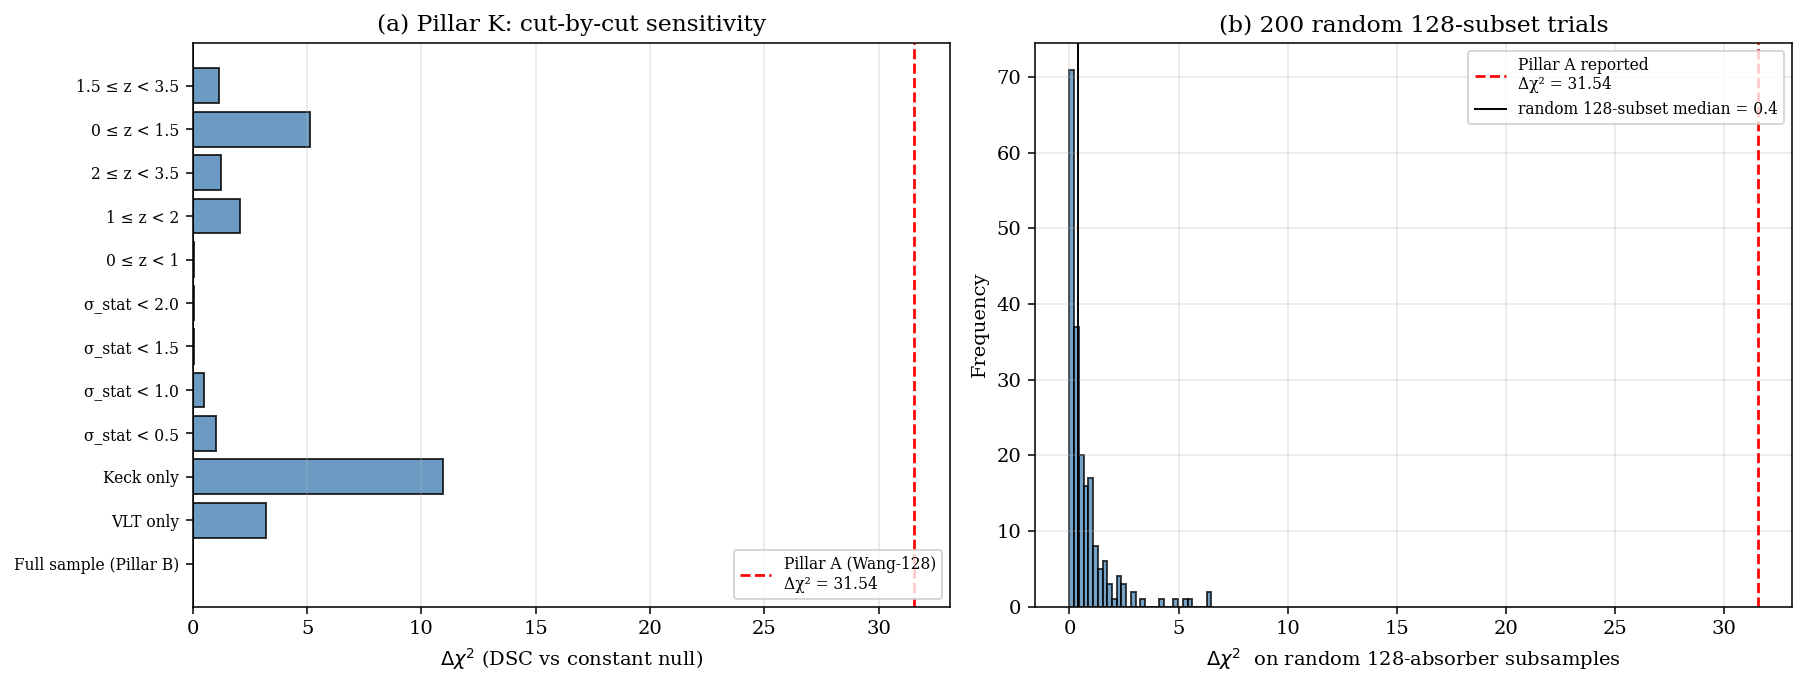

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Bar of cut-by-cut Δχ²
names_, dchis_ = zip(*[(n, r['dchi2']) for n,r in scan])
y = np.arange(len(names_))
colors = ['gray' if 'Full' in n else 'steelblue' for n in names_]
ax[0].barh(y, dchis_, color=colors, edgecolor='black', alpha=0.8)
ax[0].set_yticks(y); ax[0].set_yticklabels(names_, fontsize=8)
ax[0].axvline(31.54, color='red', ls='--', lw=1.4, label='Pillar A (Wang-128)\nΔχ² = 31.54')
ax[0].axvline(0, color='k', lw=0.5)
ax[0].set_xlabel(r'$\Delta\chi^2$ (DSC vs constant null)')
ax[0].set_title('(a) Pillar K: cut-by-cut sensitivity')
ax[0].legend(loc='lower right', fontsize=8)
ax[0].grid(axis='x', alpha=0.3)

# Distribution of random 128-subset Δχ²
ax[1].hist(dchis, bins=30, color='steelblue', alpha=0.75, edgecolor='black')
ax[1].axvline(31.54, color='red', ls='--', lw=1.4, label='Pillar A reported\nΔχ² = 31.54')
ax[1].axvline(np.median(dchis), color='black', lw=1, label=f'random 128-subset median = {np.median(dchis):.1f}')
ax[1].set_xlabel(r'$\Delta\chi^2$  on random 128-absorber subsamples')
ax[1].set_ylabel('Frequency')
ax[1].set_title(f'(b) {n_trials} random 128-subset trials')
ax[1].legend(loc='upper right', fontsize=8)
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig27_pillar_K_subset.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('fig27_subset.png', dpi=140, bbox_inches='tight', facecolor='white')
print('Saved fig27')
plt.show()